In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("USvideos.csv")

In [5]:
print("First 5 rows: \n")
print(df.head())

First 5 rows: 

      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                                tag

In [6]:
print("Statistical description of data: ")
print(df.describe())

Statistical description of data: 
        category_id         views         likes      dislikes  comment_count
count  24951.000000  2.495100e+04  2.495100e+04  2.495100e+04   2.495100e+04
mean      20.095187  1.343969e+06  4.698547e+04  2.815263e+03   5.954496e+03
std        7.585898  4.218125e+06  1.502137e+05  3.450366e+04   3.221468e+04
min        1.000000  5.490000e+02  0.000000e+00  0.000000e+00   0.000000e+00
25%       17.000000  1.282135e+05  2.598000e+03  1.150000e+02   3.545000e+02
50%       24.000000  3.803930e+05  1.074500e+04  3.790000e+02   1.165000e+03
75%       25.000000  1.120026e+06  3.258850e+04  1.233000e+03   3.655000e+03
max       43.000000  1.493761e+08  3.093544e+06  1.674420e+06   1.361580e+06


In [7]:
print(" info of data: ")
print(df.info())

 info of data: 
<class 'pandas.DataFrame'>
RangeIndex: 24951 entries, 0 to 24950
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                24951 non-null  str  
 1   trending_date           24951 non-null  str  
 2   title                   24951 non-null  str  
 3   channel_title           24951 non-null  str  
 4   category_id             24951 non-null  int64
 5   publish_time            24951 non-null  str  
 6   tags                    24951 non-null  str  
 7   views                   24951 non-null  int64
 8   likes                   24951 non-null  int64
 9   dislikes                24951 non-null  int64
 10  comment_count           24951 non-null  int64
 11  thumbnail_link          24951 non-null  str  
 12  comments_disabled       24951 non-null  bool 
 13  ratings_disabled        24951 non-null  bool 
 14  video_error_or_removed  24951 non-null  bool 
 15  description   

In [8]:
print("\nShape of data:")
print(df.shape)


Shape of data:
(24951, 16)


In [9]:
target_resgression = "views"
#calculate top 25% quantile of views
viral_threshold = df["views"].quantile(0.75)
print("\nViral Threshold:",viral_threshold)




Viral Threshold: 1120025.5


In [10]:
#Create Classification target 
df["viral"] = (df["views"] > viral_threshold).astype(int)

In [11]:
# Viral column
print("\n Viral Column:")
print(df[["views","viral"]].head(10))


 Viral Column:
     views  viral
0   748374      0
1  2418783      1
2  3191434      1
3   343168      0
4  2095731      1
5   119180      0
6  2103417      1
7   817732      0
8   826059      0
9   256426      0



 Histograms of views:



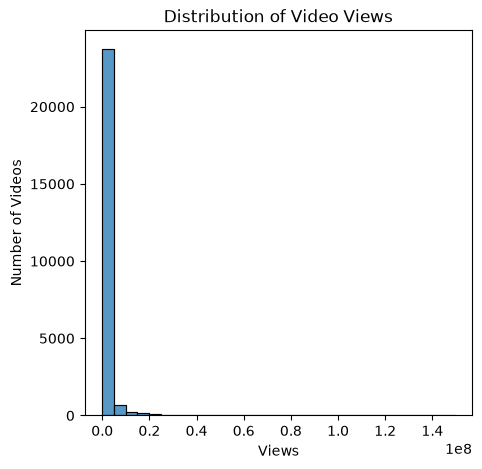

In [20]:
print("\n Histograms of views:\n")
plt.figure(figsize=(5,5))
sns.histplot(df["views"],bins=30)
plt.title("Distribution of Video Views")
plt.xlabel("Views")
plt.ylabel("Number of Videos")
plt.show()

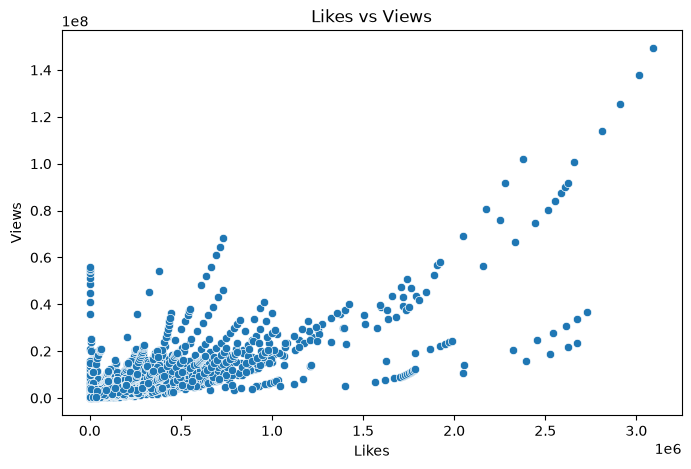

In [23]:
# Scatter plot Likes vs Views
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="likes", y="views")

plt.title("Likes vs Views")
plt.xlabel("Likes")
plt.ylabel("Views")

plt.show()

In [31]:
df["title_length"] = df["title"].str.len()


In [32]:
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m"
)

df["publish_time"] = pd.to_datetime(
    df["publish_time"],
    utc=True
)

df["days_since_publish"] = (
    df["trending_date"] -
    df["publish_time"].dt.tz_localize(None)
).dt.days

In [34]:
print(df.columns.tolist())

['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description', 'viral', 'title_length', 'days_since_publish']



Coorelation_matrix:
                        views     likes  dislikes  comment_count  title_length  \
views               1.000000  0.794761  0.512041       0.574644     -0.053863   
likes               0.794761  1.000000  0.446122       0.723176     -0.092561   
dislikes            0.512041  0.446122  1.000000       0.816315     -0.036133   
comment_count       0.574644  0.723176  0.816315       1.000000     -0.067864   
title_length       -0.053863 -0.092561 -0.036133      -0.067864      1.000000   
days_since_publish -0.026022 -0.027091 -0.007048      -0.016129     -0.065278   

                    days_since_publish  
views                        -0.026022  
likes                        -0.027091  
dislikes                     -0.007048  
comment_count                -0.016129  
title_length                 -0.065278  
days_since_publish            1.000000  


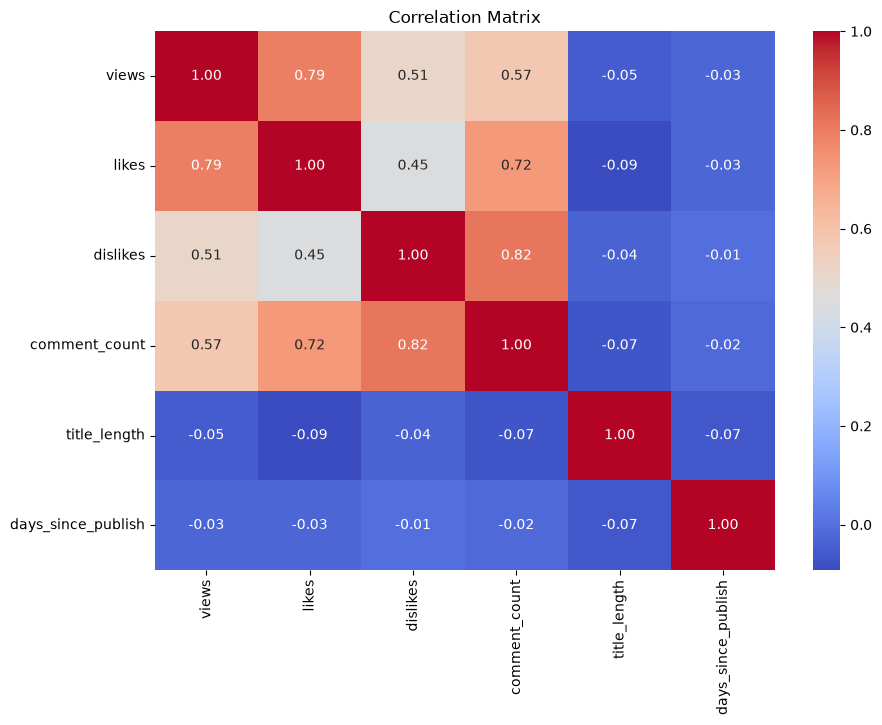

In [38]:
correlation_columns = [
    "views",
    "likes",
    "dislikes",
    "comment_count",
    "title_length",
    "days_since_publish"
]

correlation_matrix = df[correlation_columns].corr()

print("\nCoorelation_matrix:\n",correlation_matrix)
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [41]:
print("""Observations: Views have a strong positive correlation with likes(0.795)
indicating that videos with higher number of likes have higher number of views.
Moderate positive correlation comment_count(0.575) and dislikes(0.51).
Title length (-0.05) and days_since publish (-0.026) show very weak correlation
with views in this dataset.""")

Observations: Views have a strong positive correlation with likes(0.795)
indicating that videos with higher number of likes have higher number of views.
Moderate positive correlation comment_count(0.575) and dislikes(0.51).
Title length (-0.05) and days_since publish (-0.026) show very weak correlation
with views in this dataset.
